# Часть 2: Исследовательский анализ данных сервиса "Яндекс Афиша" в Python и проверка гипотез

На фоне наблюдаемого осеннего роста активности пользователей сервиса "Яндекс Афиша" и изменений в структуре спроса, команда продукта сталкивается с необходимостью глубокого понимания динамики пользовательских предпочтений. В то время как дашборд позволил выявить ключевые тренды, требуется детальный исследовательский анализ для определения глубинных причин наблюдаемых изменений и проверки гипотез о поведении различных сегментов пользователей.

- Автор:Голубова Елизавета

## Цели и задачи проекта

**Цель:** Выявить причины изменений в пользовательской активности и структуре спроса на билеты в осенний период 2024 года, а также проверить гипотезы о различиях в поведении пользователей мобильных и стационарных устройств.

**Задачи:**
1. Загрузить данные и провести их предобработку
2. Изучить сезонные изменения в пользовательском спросе
3. Проанализировать осеннюю активность пользователей
4. Выявить наиболее популярные события и ключевых партнеров
5. Проверить гипотезы о различиях в поведении пользователей мобильных и стационарных устройств
6. Сформулировать практические рекомендации для команды продукта

## Описание данных

Для анализа используются три датасета:

1. **`final_tickets_orders_df.csv`** - данные о заказах билетов с мобильных и стационарных устройств.
**Период**: 1 июня - 30 октября 2024 года
- `order_id` — уникальный идентификатор заказа;

- `user_id` — уникальный идентификатор пользователя;

- `created_dt_msk` — дата создания заказа (московское время);

- `created_ts_msk` — дата и время создания заказа (московское время);

- `event_id` — идентификатор мероприятия;

- `cinema_circuit` — сеть кинотеатров (`нет` если не применимо);

- `age_limit` — возрастное ограничение мероприятия;

- `currency_code` — валюта оплаты (`rub`/`kzt`);

- `device_type_canonical` — тип устройства (`mobile`/`desktop`);

- `revenue` — выручка от заказа;

- `service_name` — название билетного оператора;

- `tickets_count` — количество купленных билетов;

- `total` — общая сумма заказа;

- `days_since_prev` — дней с предыдущей покупки пользователя.

2. **`final_tickets_events_df.csv`** - информация о мероприятиях (фильмы исключены).
- `event_id` — уникальный идентификатор мероприятия;

- `event_name` — название мероприятия;

- `event_type_description` — описание типа мероприятия;

- `event_type_main` — основной тип мероприятия (концерт, театральная постановка и др.);

- `organizers` — организаторы мероприятия;

- `region_name` — название региона;

- `city_name` — название города;

- `city_id` — идентификатор города;

- `venue_id` — уникальный идентификатор площадки;

- `venue_name` — название площадки;

- `venue_address` — адрес площадки.
3. **`final_tickets_tenge_df.csv`** - информация о курсе тенге к российскому рублю за 2024 год.
- `nominal` — номинал (100 тенге);

- `data` — дата;

- `curs` — курс тенге к рублю;

- `cdx` — обозначение валюты (`kzt`).

## Содержание проекта
1. Загрузка данных и знакомство с ними
2. Предобработка данных и подготовка их к исследованию
3. Исследовательский анализ данных
4. Статистический анализ данных
5. Общий вывод и рекомендации

---

## 1. Загрузка данных и знакомство с ними

In [1]:
# Загружаем библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from matplotlib.patches import Patch

In [2]:
# Загружаем данные
orders = pd.read_csv('/datasets/final_tickets_orders_df.csv')
events = pd.read_csv('/datasets/final_tickets_events_df.csv')
tenge = pd.read_csv('/datasets/final_tickets_tenge_df.csv')

In [3]:
# Выводим информацию о датафрейме orders
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290849 entries, 0 to 290848
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   order_id               290849 non-null  int64  
 1   user_id                290849 non-null  object 
 2   created_dt_msk         290849 non-null  object 
 3   created_ts_msk         290849 non-null  object 
 4   event_id               290849 non-null  int64  
 5   cinema_circuit         290849 non-null  object 
 6   age_limit              290849 non-null  int64  
 7   currency_code          290849 non-null  object 
 8   device_type_canonical  290849 non-null  object 
 9   revenue                290849 non-null  float64
 10  service_name           290849 non-null  object 
 11  tickets_count          290849 non-null  int64  
 12  total                  290849 non-null  float64
 13  days_since_prev        268909 non-null  float64
dtypes: float64(3), int64(4), object(7)
m

In [4]:
# Выводим первые строки датафрейма orders
orders.head()

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,Край билетов,4,10870.99,NaN
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,Мой билет,2,2067.51,NaN
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.57,За билетом!,4,13984.16,75.0
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.49,Лови билет!,2,212.28,NaN
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.41,Билеты без проблем,3,10695.43,83.0


Датасет содержит *290 849 строк* и *14 столбцов* с информацией о заказах билетов на мероприятия.

Изучим типы данных и их корректность:

**Семь столбцов имеют числовые типы**:

- `order_id`, `event_id`, `age_limit`, `tickets_count` - целочисленные данные, имеют тип `int64`. Для оптимизации памяти можно преобразовать в `int16`.

- `revenue`, `total`, `days_since_prev` - данные имеют тип `float64`. Для выручки и суммы корректный тип, можно оптимизировать в `float32`.

**Семь столбцов имеют тип `object`**:

- `user_id`, `created_dt_msk`, `created_ts_msk` - содержат строковую информацию, но `created_dt_msk` и `created_ts_msk` следует преобразовать в `datetime`.

- `cinema_circuit`, `currency_code`, `device_type_canonical`, `service_name` - категориальные данные, можно преобразовать в тип `category` для оптимизации памяти.

**Особенности данных:**

- Пропуски только в `days_since_prev` (21 940 значений) - это ожидаемо для первых покупок пользователей.

- Дата и время хранятся как строки, требуют преобразования.

- Категориальные данные занимают много памяти в формате `object`.

In [5]:
# Выводим информацию о датафрейме events
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22427 entries, 0 to 22426
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   event_id                22427 non-null  int64 
 1   event_name              22427 non-null  object
 2   event_type_description  22427 non-null  object
 3   event_type_main         22427 non-null  object
 4   organizers              22427 non-null  object
 5   region_name             22427 non-null  object
 6   city_name               22427 non-null  object
 7   city_id                 22427 non-null  int64 
 8   venue_id                22427 non-null  int64 
 9   venue_name              22427 non-null  object
 10  venue_address           22427 non-null  object
dtypes: int64(3), object(8)
memory usage: 1.9+ MB


In [6]:
# Выводим первые строки датафрейма events
events.head()

,event_id,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
0,4436,e4f26fba-da77-4c61-928a-6c3e434d793f,спектакль,театр,№4893,Североярская область,Озёрск,2,1600,"Кладбище искусств ""Проблема"" и партнеры","наб. Загородная, д. 785"
1,5785,5cc08a60-fdea-4186-9bb2-bffc3603fb77,спектакль,театр,№1931,Светополянский округ,Глиноград,54,2196,"Лекции по искусству ""Свет"" Групп","ул. Ягодная, д. 942"
2,8817,8e379a89-3a10-4811-ba06-ec22ebebe989,спектакль,театр,№4896,Североярская область,Озёрск,2,4043,"Кинокомитет ""Золотая"" Инк","ш. Коммуны, д. 92 стр. 6"
3,8849,682e3129-6a32-4952-9d8a-ef7f60d4c247,спектакль,театр,№4960,Каменевский регион,Глиногорск,213,1987,"Выставка ремесел ""Свет"" Лтд","пер. Набережный, д. 35"
4,8850,d6e99176-c77f-4af0-9222-07c571f6c624,спектакль,театр,№4770,Лесодальний край,Родниковец,55,4230,"Фестивальный проект ""Листья"" Групп","пер. Проезжий, д. 9"


Датасет содержит *22 427 строк* и *11 столбцов* с информацией о мероприятиях.

**Три столбца имеют тип `int64`**:

- `event_id`, `city_id`, `venue_id` - целочисленные идентификаторы, можно оптимизировать в `int32`.

**Восемь столбцов имеют тип `object`**:

- `event_name`, `event_type_description`, `event_type_main`, `organizers` - текстовые описания, можно оставить как `object`.

- `region_name`, `city_name`, `venue_name`, `venue_address` - категориальные данные, можно преобразовать в `category`.

**Особенности данных**:

- Нет пропусков во всех столбцах.

- Названия мероприятий закодированы.

In [7]:
# Выводим информацию о датафрейме tenge
tenge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    object 
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 11.3+ KB


In [8]:
# Выводим первые строки датафрейма tenge
tenge.head()

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


Датасет содержит *357 строк* и *4 столбца* с информацией о курсе тенге к рублю.

**Числовые значения**:

- `nominal` - целое число (100), тип `int64`, можно преобразовать в `int8`.

- `curs` - курс с плавающей запятой, тип `float64`, можно оптимизировать в `float32`.

**Строковые данные (`object`)**:

- `data` - дата в строковом формате, требуется преобразование в `datetime`.

- `cdx` - код валюты (всегда 'kzt'), можно преобразовать в `category`.

**Особенности данных**:

- Нет пропусков.

- Данные за весь 2024 год.

- Номинал всегда равен 100 (тенге).

**ВЫВОД**
После анализа типов данных видно, что все три датасета в целом корректно представлены, но требуют оптимизации.Названия столбцов соответствуют snake_case и не требуют переименования. Все данные соответствуют описанию задания и готовы к дальнейшей предобработке.

## 2. Предобработка данных и подготовка их к исследованию

### 2.1. Изучение категоральных значений

In [9]:
# Устройства
print("Типы устройств:")
print(orders['device_type_canonical'].value_counts())

Типы устройств:
mobile     232679
desktop     58170
Name: device_type_canonical, dtype: int64


In [10]:
# Валюты  
print("\nВалюты:")
print(orders['currency_code'].value_counts())


Валюты:
rub    285780
kzt      5069
Name: currency_code, dtype: int64


In [11]:
# Сети кинотеатров
print("\nСети кинотеатров:")
print(orders['cinema_circuit'].value_counts())


Сети кинотеатров:
нет           289451
Другое          1261
КиноСити         122
Киномакс           7
Москино            7
ЦентрФильм         1
Name: cinema_circuit, dtype: int64


In [12]:
# Билетные операторы
print(f"Уникальных значений: {orders['service_name'].nunique()}")
print("\nБилетные операторы:")
print(orders['service_name'].value_counts())

Уникальных значений: 36

Билетные операторы:
Билеты без проблем        63709
Лови билет!               41126
Билеты в руки             40364
Мой билет                 34843
Облачко                   26642
Лучшие билеты             17795
Весь в билетах            16849
Прачечная                 10273
Край билетов               6207
Тебе билет!                5228
Яблоко                     5039
Дом культуры               4502
За билетом!                2865
Городской дом культуры     2733
Show_ticket                2200
Мир касс                   2167
Быстробилет                2003
Выступления.ру             1616
Восьмёрка                  1118
Crazy ticket!               790
Росбилет                    539
Шоу начинается!             499
Быстрый кассир              381
Радио ticket                376
Телебилет                   321
КарандашРУ                  133
Реестр                      125
Билет по телефону            85
Вперёд!                      80
Дырокол                    

In [13]:
# Возрастные ограничения
print("\nВозрастные ограничения:")
print(orders['age_limit'].value_counts().sort_index())


Возрастные ограничения:
0     61487
6     52173
12    62557
16    78579
18    36053
Name: age_limit, dtype: int64


In [14]:
# Типы мероприятий
print("\nТипы мероприятий:")
print(events['event_type_main'].value_counts())


Типы мероприятий:
концерты    8680
театр       7076
другое      4658
спорт        872
стендап      636
выставки     290
ёлки         215
Name: event_type_main, dtype: int64


In [15]:
# Регионы
print(f"Уникальных значений: {events['region_name'].nunique()}")
print("\nРегионы:")
print(events['region_name'].value_counts())

Уникальных значений: 81

Регионы:
Каменевский регион          5983
Североярская область        3814
Широковская область         1233
Светополянский округ        1075
Речиновская область          702
                            ... 
Верхозёрский край              2
Теплоозёрский округ            2
Сосноводолинская область       2
Светолесский край              2
Лесноярский край               2
Name: region_name, Length: 81, dtype: int64


**ВЫВОД ПО КАТЕГОРИАЛЬНЫМ ЗНАЧЕНИЯМ:**
Все категориальные значения корректны:

- Устройства: Только `mobile` (80%) и `desktop` (20%) - соответствует условию

- Валюты: `rub` (98%) и `kzt` (2%) - корректные коды валют

- Сети кинотеатров: В основном `нет` (99.5%) - корректное обозначение отсутствия сети

- Билетные операторы: 36 уникальных названий, все выглядят корректно

- Возрастные ограничения: `0`, `6`, `12`, `16`, `18` - стандартные категории, распределены равномерно

- Типы мероприятий: 7 категорий, лидеры - концерты и театр, фильмы исключены (как указано)

- Регионы: 81 уникальный регион, данные распределены неравномерно

*Ошибок в данных не обнаружено. Значения соответствуют описанию, отсутствуют некорректные кодировки пропусков. Нормализация не требуется. Данные готовы для дальнейшей предобработки.*

### 2.2. Изучение количественных значений

In [16]:
# Статистика по выручке и количеству билетов
orders[['revenue', 'tickets_count', 'total']].describe()

,revenue,tickets_count,total
count,290849.000000,290849.000000,290849.000000
mean,625.083054,2.754230,7526.465613
std,1227.316214,1.170467,15328.267730
min,-90.760000,1.000000,-358.850000
25%,116.790000,2.000000,2156.870000
50%,355.340000,3.000000,4771.390000
75%,809.750000,4.000000,8955.950000
max,81174.540000,57.000000,811745.400000


1. **Данные имеют выбросы**: максимальная выручка в 100 раз превышает 75-й процентиль

2. **Есть аномалии**: отрицательные значения выручки и заказы на 57 билетов

3. **Требуется очистка**: фильтрация по 99-му процентилю и обработка отрицательных значений

In [18]:
# Анализ по валютам
# Рубли (RUB)
print("\nРУБЛИ (RUB):")
rub_orders = orders[orders['currency_code'] == 'rub'].copy()
rub_orders[['revenue', 'tickets_count']].describe()


РУБЛИ (RUB):


,revenue,tickets_count
count,285780.000000,285780.000000
mean,547.568333,2.754077
std,871.524559,1.171419
min,-90.760000,1.000000
25%,113.827500,2.000000
50%,346.100000,3.000000
75%,791.700000,4.000000
max,81174.540000,57.000000


In [19]:
# Тенге (KZT) 
print("\nТЕНГЕ (KZT):")
kzt_orders = orders[orders['currency_code'] == 'kzt'].copy()
kzt_orders[['revenue', 'tickets_count']].describe()


ТЕНГЕ (KZT):


,revenue,tickets_count
count,5069.000000,5069.000000
mean,4995.206767,2.762872
std,4916.752776,1.115558
min,0.000000,1.000000
25%,518.100000,2.000000
50%,3698.830000,3.000000
75%,7397.660000,4.000000
max,26425.860000,6.000000


In [20]:
# Проверка выбросов через процентили
# Для рублей
print("\nРубли - 99-й процентиль:")
revenue_99_rub = rub_orders['revenue'].quantile(0.99)
tickets_99_rub = rub_orders['tickets_count'].quantile(0.99)
print(f"revenue 99%: {revenue_99_rub:.2f} руб")
print(f"tickets_count 99%: {tickets_99_rub} билетов")

# Для тенге
print("\nТенге - 99-й процентиль:")
revenue_99_kzt = kzt_orders['revenue'].quantile(0.99)
tickets_99_kzt = kzt_orders['tickets_count'].quantile(0.99)
print(f"revenue 99%: {revenue_99_kzt:.2f} тенге")
print(f"tickets_count 99%: {tickets_99_kzt} билетов")


Рубли - 99-й процентиль:
revenue 99%: 2569.59 руб
tickets_count 99%: 6.0 билетов

Тенге - 99-й процентиль:
revenue 99%: 17617.24 тенге
tickets_count 99%: 6.0 билетов


1. **Выбросы есть в обеих валютах**: 99-й процентиль значительно ниже максимумов

- RUB: максимум 81,174 vs 99% = 2 570 руб

- KZT: максимум 26,426 vs 99% = 17 617 тенге

2. **Выбросы сильнее в рублях**: 

- Максимум в 32 раза выше 99-го процентиля

- В тенге: только в 1.5 раза выше

3. **Билеты**: 99-й процентиль = 6 билетов, но есть заказы на 57 билетов (RUB)

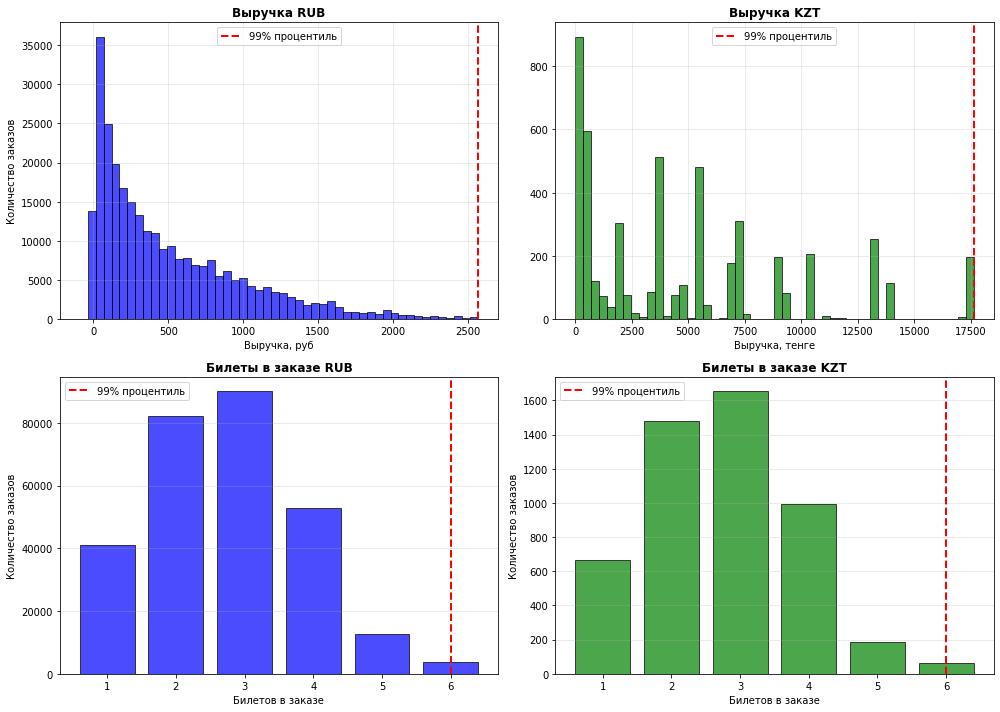

In [22]:
# Фильтруем выбросы для рублей
rub_orders_filtered = rub_orders[
    (rub_orders['revenue'] <= revenue_99_rub) & 
    (rub_orders['tickets_count'] <= tickets_99_rub)
].copy()

# Фильтруем выбросы для тенге
kzt_orders_filtered = kzt_orders[
    (kzt_orders['revenue'] <= revenue_99_kzt) & 
    (kzt_orders['tickets_count'] <= tickets_99_kzt)
].copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Выручка в рублях
axes[0, 0].hist(rub_orders_filtered['revenue'], bins=50, alpha=0.7, color='blue', edgecolor='black')
axes[0, 0].axvline(x=revenue_99_rub, color='red', linestyle='--', linewidth=2, label='99% процентиль')
axes[0, 0].set_title('Выручка RUB', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Выручка, руб', fontsize=10)
axes[0, 0].set_ylabel('Количество заказов', fontsize=10)
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Выручка в тенге
axes[0, 1].hist(kzt_orders_filtered['revenue'], bins=50, alpha=0.7, color='green', edgecolor='black')
axes[0, 1].axvline(x=revenue_99_kzt, color='red', linestyle='--', linewidth=2, label='99% процентиль')
axes[0, 1].set_title('Выручка KZT', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Выручка, тенге', fontsize=10)
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Количество билетов в рублях
max_tickets_to_show = min(10, int(tickets_99_rub) + 2)
ticket_counts_rub_after = rub_orders_filtered['tickets_count'].value_counts().sort_index()
axes[1, 0].bar(ticket_counts_rub_after.index[:max_tickets_to_show], 
               ticket_counts_rub_after.values[:max_tickets_to_show], 
               alpha=0.7, color='blue', edgecolor='black')
axes[1, 0].axvline(x=tickets_99_rub, color='red', linestyle='--', linewidth=2, label='99% процентиль')
axes[1, 0].set_title('Билеты в заказе RUB', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Билетов в заказе', fontsize=10)
axes[1, 0].set_ylabel('Количество заказов', fontsize=10)
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3)

# Количество билетов в тенге
max_tickets_to_show_kzt = min(10, int(tickets_99_kzt) + 2)
ticket_counts_kzt_after = kzt_orders_filtered['tickets_count'].value_counts().sort_index()
axes[1, 1].bar(ticket_counts_kzt_after.index[:max_tickets_to_show_kzt], 
               ticket_counts_kzt_after.values[:max_tickets_to_show_kzt], 
               alpha=0.7, color='green', edgecolor='black')
axes[1, 1].axvline(x=tickets_99_kzt, color='red', linestyle='--', linewidth=2, label='99% процентиль')
axes[1, 1].set_title('Билеты в заказе KZT', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Билетов в заказе', fontsize=10)
axes[1, 1].set_ylabel('Количество заказов', fontsize=10)
axes[1, 1].legend()
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

1. **Выручка имеет "длинный хвост"**: Большинство заказов до 99-го процентиля (2 570 руб / 17 617 тенге)

2. **Пики распределения**: Основная масса заказов сконцентрирована в низком ценовом диапазоне

3. **Количество билетов**: 2-4 билета - наиболее популярное количество

4. **Визуальное подтверждение**: 99-й процентиль отсекает явные выбросы

### 2.3. Проверка дубликатов

In [23]:
# Явные дубликаты
print("Полные дубликаты заказов:", orders.duplicated().sum())
print("Полные дубликаты мероприятий:", events.duplicated().sum())

Полные дубликаты заказов: 0
Полные дубликаты мероприятий: 0


In [24]:
# Дубликаты order_id
print("Дубликаты order_id:", orders['order_id'].duplicated().sum())

Дубликаты order_id: 0


In [25]:
# Неявные дубликаты (без order_id)
#columns_without_id = ['user_id', 'created_dt_msk', 'event_id', 'cinema_circuit', 
                     # 'age_limit', 'currency_code', 'device_type_canonical', 
                     #'revenue', 'service_name', 'tickets_count', 'total', 'days_since_prev']
#print("Неявные дубликаты (без order_id):", orders.duplicated(subset=columns_without_id).sum())

In [26]:
# Неявные дубликаты (все столбцы кроме order_id)
cols = [col for col in orders.columns if col != 'order_id']
duplicates = orders.duplicated(subset=cols).sum()
print(f"Неявных дубликатов: {duplicates}")

Неявных дубликатов: 30


In [27]:
# Просмотр примеров дубликатов
if orders.duplicated(subset=cols).sum() > 0:
    duplicates = orders[orders.duplicated(subset=cols, keep=False)]
    print(f"\nПример неявных дубликатов (первые 10 записей):")
    display(duplicates.head(10).sort_values(by=['user_id', 'created_dt_msk']))


Пример неявных дубликатов (первые 10 записей):


,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev
11777,1123983,06eb7897f65b433,2024-08-13,2024-08-13 16:31:07,183706,нет,18,rub,mobile,69.82,Билеты в руки,1,997.48,0.0
11778,1123867,06eb7897f65b433,2024-08-13,2024-08-13 16:31:07,183706,нет,18,rub,mobile,69.82,Билеты в руки,1,997.48,0.0
57217,160922,2564e3703075008,2024-10-30,2024-10-30 10:04:15,589005,нет,6,rub,mobile,11.23,Лови билет!,2,280.81,0.0
57220,160893,2564e3703075008,2024-10-30,2024-10-30 10:04:15,589005,нет,6,rub,mobile,11.23,Лови билет!,2,280.81,0.0
84010,3363711,3ee7dc2e115847f,2024-06-25,2024-06-25 07:32:08,277504,нет,6,rub,mobile,59.19,Билеты в руки,3,739.85,0.0
84015,3363798,3ee7dc2e115847f,2024-06-25,2024-06-25 07:32:08,277504,нет,6,rub,mobile,59.19,Билеты в руки,3,739.85,0.0
148473,2324032,7b525118ae656af,2024-10-28,2024-10-28 08:33:04,588203,нет,0,rub,mobile,26.96,Лучшие билеты,4,674.12,0.0
148477,2323916,7b525118ae656af,2024-10-28,2024-10-28 08:33:04,588203,нет,0,rub,mobile,26.96,Лучшие билеты,4,674.12,0.0
154170,5372628,7eb4fc207ecc10f,2024-08-23,2024-08-23 14:08:19,298035,нет,6,rub,mobile,126.84,Билеты без проблем,1,3170.95,0.0
154173,5372831,7eb4fc207ecc10f,2024-08-23,2024-08-23 14:08:19,298035,нет,6,rub,mobile,126.84,Билеты без проблем,1,3170.95,0.0


**ВЫВОД ПО ДУБЛИКАТАМ:**

- *Явных дубликатов нет*: Полные копии строк и дубликаты ID отсутствуют

- *Найдены неявные дубликаты*: 30 (0.01% данных)

**Причина дубликатов**: Разные пользователи покупают билеты на одно мероприятие в одно и то же время

**Решение**:

- *Сохранить все записи* - это реальные покупки, а не ошибки данных

- *Учесть в анализе* - пользователи могут делать несколько покупок

- *Не удалять* - дубликаты обоснованы бизнес-логикой

### 2.4. Преобразование типов данных

In [28]:
# Даты в orders
orders['created_dt_msk'] = pd.to_datetime(orders['created_dt_msk'])
orders['created_ts_msk'] = pd.to_datetime(orders['created_ts_msk'])

# Даты в tenge
tenge['data'] = pd.to_datetime(tenge['data'])

In [29]:
# Оптимизация числовых типов в orders
# Целые числа
orders['order_id'] = orders['order_id'].astype('int32')
orders['event_id'] = orders['event_id'].astype('int32')
orders['age_limit'] = orders['age_limit'].astype('int16')
orders['tickets_count'] = orders['tickets_count'].astype('int16')

# Дробные числа
orders['revenue'] = orders['revenue'].astype('float32')
orders['total'] = orders['total'].astype('float32')
orders['days_since_prev'] = orders['days_since_prev'].astype('float32')

In [30]:
# Категориальные данные в orders
cat_cols = ['cinema_circuit', 'currency_code', 'device_type_canonical', 'service_name']
for col in cat_cols:
    orders[col] = orders[col].astype('category')

In [31]:
# Оптимизация events
events['event_id'] = events['event_id'].astype('int32')
events['city_id'] = events['city_id'].astype('int32')
events['venue_id'] = events['venue_id'].astype('int32')

# Категориальные в events
events['region_name'] = events['region_name'].astype('category')
events['city_name'] = events['city_name'].astype('category')

In [32]:
# Оптимизация tenge
tenge['nominal'] = tenge['nominal'].astype('int8')
tenge['curs'] = tenge['curs'].astype('float32')
tenge['cdx'] = tenge['cdx'].astype('category')

### 2.5. Создание новых столюцов

In [33]:
# Объединяем данные о заказах и событиях
df = orders.merge(events, on='event_id', how='left')

In [34]:
# 1. Конвертация валюты: создаем revenue_rub
# Для тенге используем курс на дату заказа
# Подготавливаем курс тенге: пересчитываем на 1 тенге и переименовываем для удобства
tenge['curs_per_one'] = tenge['curs'] / 100  # курс 1 тенге в рублях
tenge['date'] = tenge['data'] 

# Добавляем курс к данным о заказах
df = df.merge(tenge[['date', 'curs_per_one']], 
              left_on='created_dt_msk', 
              right_on='date', 
              how='left')

# Конвертируем в рубли
def convert_to_rub(row):
    if row['currency_code'] == 'kzt':
        return row['revenue'] * row['curs_per_one']
    else:
        return row['revenue']

df['revenue_rub'] = df.apply(convert_to_rub, axis=1)
df['revenue_rub'] = df['revenue_rub'].astype('float32')

# Удаляем временные столбцы
df.drop(['date', 'curs_per_one'], axis=1, inplace=True)

In [35]:
# Выручка с одного билета
df['one_ticket_revenue_rub'] = df['revenue_rub'] / df['tickets_count']
df['one_ticket_revenue_rub'] = df['one_ticket_revenue_rub'].astype('float32')

In [36]:
# Месяц оформления заказа
df['month'] = df['created_dt_msk'].dt.month

In [37]:
# Сезонность
def get_season(month):
    if month in [12, 1, 2]:
        return 'зима'
    elif month in [3, 4, 5]:
        return 'весна'
    elif month in [6, 7, 8]:
        return 'лето'
    else:
        return 'осень'

df['season'] = df['month'].apply(get_season)
df['season'] = df['season'].astype('category')

Новые столбцы созданы:
- `revenue_rub` - выручка в рублях (конвертирована для KZT)
- `one_ticket_revenue_rub` - выручка с одного билета в рублях
- `month` - месяц оформления заказа (1-12)
- `season` - сезон ('лето', 'осень', 'зима', 'весна')

Размер датафрейма после объединения: 290 849 строк, 28 столбцов

Распределение заказов по сезонам:
- осень - 170 197 (58.5%)
- лето - 120 652 (41.5%)

После отсечения по 99-му процентилю для выручки:

- Для рублей: отсечено 2 900 заказов (1.0% от всех RUB заказов)
- Для тенге: отсечено 57 заказов (1.0% от всех KZT заказов)
- Общая доля срезанных данных: 1.0% (2 957 из 290 849 заказов)

## 3. Исследовательский анализ данных

### 3.1. Анализ распределения заказов по сегментам и их сезонные изменения

In [38]:
# Подготовка данных для сравнения лета и осени
summer_df = df[df['season'] == 'лето']
autumn_df = df[df['season'] == 'осень']

# Функция для расчета долей по категориям
def calculate_seasonal_shares(df_season, category_column):
    shares = df_season[category_column].value_counts(normalize=True) * 100
    return shares.sort_index()

Количество заказов по месяцам:
month
6      34683
7      40925
8      45044
9      69976
10    100221
Name: order_id, dtype: int64


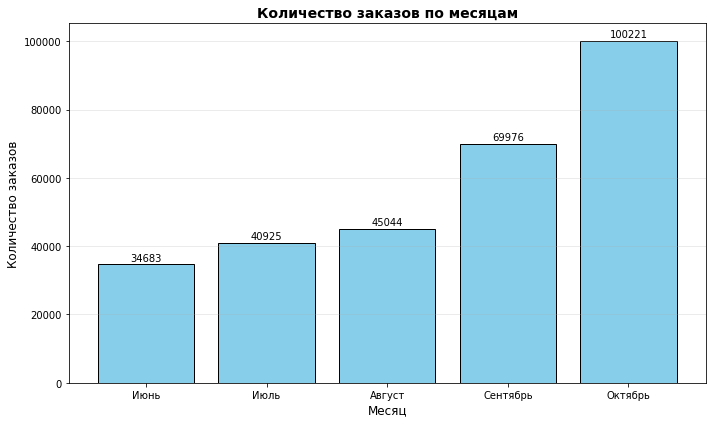


Анализ динамики
Июнь: 34683 заказов
Октябрь: 100221 заказов
Рост: 189.0%

Месячный рост заказов:
Июнь → Июль: 18.0%
Июль → Август: 10.1%
Август → Сентябрь: 55.4%
Сентябрь → Октябрь: 43.2%


In [39]:
# Анализ заказов по месяцам
print("Количество заказов по месяцам:")
monthly_orders = df.groupby('month')['order_id'].count()
print(monthly_orders)

month_names = {
    6: 'Июнь',
    7: 'Июль', 
    8: 'Август',
    9: 'Сентябрь',
    10: 'Октябрь'
}

# Визуализация заказов по месяцам
plt.figure(figsize=(10, 6))

# Сортируем по месяцам
monthly_orders_sorted = monthly_orders.sort_index()

# Создаем график
months_available = [month_names[m] for m in monthly_orders_sorted.index]
x_pos = range(len(months_available))

plt.bar(x_pos, monthly_orders_sorted.values, color='skyblue', edgecolor='black')
plt.title('Количество заказов по месяцам', fontsize=14, fontweight='bold')
plt.xlabel('Месяц', fontsize=12)
plt.ylabel('Количество заказов', fontsize=12)
plt.xticks(x_pos, months_available, rotation=0)
plt.grid(axis='y', alpha=0.3)

# Добавляем значения на столбцы
for i, v in enumerate(monthly_orders_sorted.values):
    plt.text(i, v + 1000, f'{v:}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

# Анализ динамики
print("\nАнализ динамики")
june_orders = monthly_orders_sorted[6]
october_orders = monthly_orders_sorted[10]

growth = ((october_orders - june_orders) / june_orders) * 100
print(f"Июнь: {june_orders:} заказов")
print(f"Октябрь: {october_orders:} заказов")
print(f"Рост: {growth:.1f}%")

# Проверяем рост от месяца к месяцу
print("\nМесячный рост заказов:")
for i in range(len(monthly_orders_sorted)-1):
    current_month = monthly_orders_sorted.index[i]
    next_month = monthly_orders_sorted.index[i+1]
    current_orders = monthly_orders_sorted[current_month]
    next_orders = monthly_orders_sorted[next_month]
    month_growth = ((next_orders - current_orders) / current_orders) * 100
    print(f"{month_names[current_month]} → {month_names[next_month]}: {month_growth:.1f}%")

Фиксируется значительное увеличение заказов от июня к октябрю 2024 года. Количество заказов выросло с 34 683 в июне до 100 221 в октябре, что составляет рост на 189.0%.

Наиболее интенсивный рост наблюдается в осенние месяцы:

- сентябрьский скачок +55.4% по сравнению с августом

- октябрьский рост +43.2% по сравнению с сентябрем

Летние месяцы также показывают положительную динамику (+18.0% и +10.1%), но осенний рост значительно превышает летний, что подтверждает сезонность спроса на культурно-развлекательные мероприятия.

In [40]:
# Сравнение распределения по типам мероприятий
event_type_summer = calculate_seasonal_shares(summer_df, 'event_type_main')
event_type_autumn = calculate_seasonal_shares(autumn_df, 'event_type_main')

# Создаем DataFrame для сравнения
event_comparison = pd.DataFrame({
    'Лето (%)': event_type_summer,
    'Осень (%)': event_type_autumn
}).fillna(0)

# Добавляем абсолютные значения
event_comparison['Лето (абс.)'] = summer_df['event_type_main'].value_counts()
event_comparison['Осень (абс.)'] = autumn_df['event_type_main'].value_counts()
event_comparison['Изменение (п.п.)'] = event_comparison['Осень (%)'] - event_comparison['Лето (%)']

# Сортируем по убыванию доли осенью
event_comparison = event_comparison.sort_values('Осень (%)', ascending=False)

print(f"\nДоля заказов по типам мероприятий:")
display(event_comparison[['Лето (%)', 'Осень (%)', 'Изменение (п.п.)', 
                          'Лето (абс.)', 'Осень (абс.)']].round(1))


Доля заказов по типам мероприятий:


,Лето (%),Осень (%),Изменение (п.п.),Лето (абс.),Осень (абс.)
концерты,42.8,37.5,-5.3,51539,63737
театр,20.1,25.3,5.2,24215,43106
другое,27.0,19.6,-7.5,32575,33292
спорт,2.5,11.1,8.6,3013,18898
стендап,5.3,4.1,-1.2,6401,6992
выставки,2.0,1.4,-0.6,2417,2437
ёлки,0.2,1.0,0.8,276,1713


In [41]:
# Сравнение распределения по типам устройств
device_summer = calculate_seasonal_shares(summer_df, 'device_type_canonical')
device_autumn = calculate_seasonal_shares(autumn_df, 'device_type_canonical')

device_comparison = pd.DataFrame({
    'Лето (%)': device_summer,
    'Осень (%)': device_autumn
})

device_comparison['Лето (абс.)'] = summer_df['device_type_canonical'].value_counts()
device_comparison['Осень (абс.)'] = autumn_df['device_type_canonical'].value_counts()
device_comparison['Изменение (п.п.)'] = device_comparison['Осень (%)'] - device_comparison['Лето (%)']

# Сортируем по убыванию доли осенью
device_comparison = device_comparison.sort_values('Осень (%)', ascending=False)

print(f"\nДоля заказов по типам устройств:")
display(device_comparison[['Лето (%)', 'Осень (%)', 'Изменение (п.п.)', 
                           'Лето (абс.)', 'Осень (абс.)']].round(1))


Доля заказов по типам устройств:


,Лето (%),Осень (%),Изменение (п.п.),Лето (абс.),Осень (абс.)
mobile,80.5,79.6,-0.9,97173,135506
desktop,19.5,20.4,0.9,23479,34691


In [42]:
# Сравнение распределения по возрастным рейтингам
age_summer = calculate_seasonal_shares(summer_df, 'age_limit')
age_autumn = calculate_seasonal_shares(autumn_df, 'age_limit')

age_comparison = pd.DataFrame({
    'Лето (%)': age_summer,
    'Осень (%)': age_autumn
})

age_comparison['Лето (абс.)'] = summer_df['age_limit'].value_counts()
age_comparison['Осень (абс.)'] = autumn_df['age_limit'].value_counts()
age_comparison['Изменение (п.п.)'] = age_comparison['Осень (%)'] - age_comparison['Лето (%)']

# Сортируем по возрастному рейтингу от 0 до 18
age_comparison = age_comparison.sort_index()

print(f"\nДоля заказов по возрастным рейтингам:")
display(age_comparison[['Лето (%)', 'Осень (%)', 'Изменение (п.п.)', 
                        'Лето (абс.)', 'Осень (абс.)']].round(1))


Доля заказов по возрастным рейтингам:


,Лето (%),Осень (%),Изменение (п.п.),Лето (абс.),Осень (абс.)
0,17.9,23.4,5.5,21615,39872
6,18.2,17.7,-0.5,21973,30200
12,20.6,22.1,1.5,24874,37683
16,28.2,26.2,-2.0,34034,44545
18,15.0,10.5,-4.5,18156,17897


In [43]:
# Рассчитываем среднюю стоимость билета
summer_prices = df[df['season'] == 'лето'].groupby('event_type_main')['one_ticket_revenue_rub'].mean()
autumn_prices = df[df['season'] == 'осень'].groupby('event_type_main')['one_ticket_revenue_rub'].mean()

# 2. Создаем DataFrame
data = []
event_types = [et for et in df['event_type_main'].dropna().unique()]

for event_type in event_types:
    summer_price = summer_prices.get(event_type, 0)
    autumn_price = autumn_prices.get(event_type, 0)
    
    if summer_price > 0:
        change_pct = ((autumn_price - summer_price) / summer_price * 100)
    else:
        change_pct = 0
    
    data.append({
        'Тип мероприятия': str(event_type),
        'Лето (руб)': round(summer_price, 0),
        'Осень (руб)': round(autumn_price, 0),
        'Изменение (%)': round(change_pct, 1),
        'Изменение (руб)': round(autumn_price - summer_price, 0)
    })

price_df = pd.DataFrame(data)

# Выводим результат
print("Средняя стоимость билета по типам мероприятий:")
display(price_df)

Средняя стоимость билета по типам мероприятий:


,Тип мероприятия,Лето (руб),Осень (руб),Изменение (%),Изменение (руб)
0,театр,223.0,183.0,-17.7,-39.0
1,выставки,86.0,91.0,5.4,5.0
2,другое,81.0,77.0,-4.9,-4.0
3,стендап,227.0,250.0,10.1,23.0
4,концерты,319.0,287.0,-10.1,-32.0
5,спорт,54.0,52.0,-3.7,-2.0
6,ёлки,276.0,235.0,-15.2,-42.0


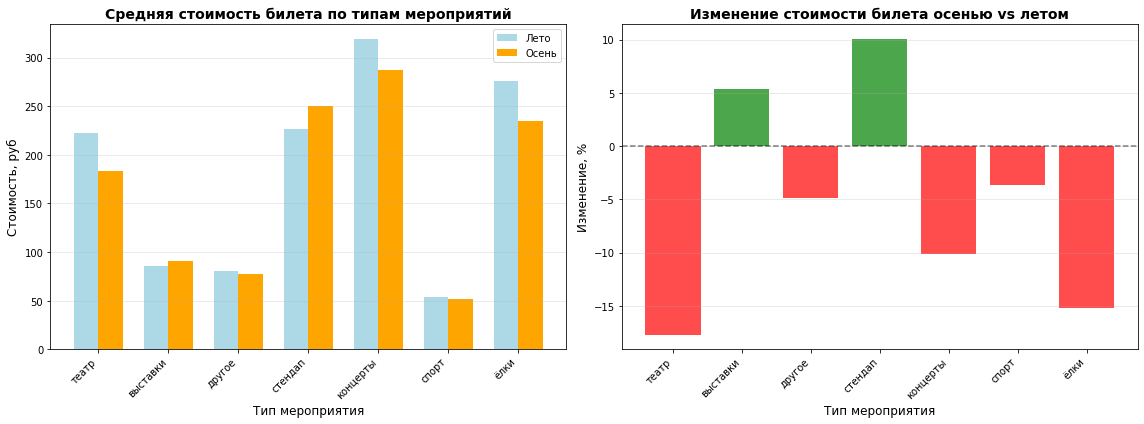

In [44]:
# Визуализация
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# График 1: Сравнение стоимости летом и осенью
events = price_df['Тип мероприятия']
x = range(len(events))
width = 0.35

bars1 = ax1.bar(x, price_df['Лето (руб)'], width=width, label='Лето', color='lightblue')
bars2 = ax1.bar([i + width for i in x], price_df['Осень (руб)'], width=width, label='Осень', color='orange')

ax1.set_title('Средняя стоимость билета по типам мероприятий', fontsize=14, fontweight='bold')
ax1.set_xlabel('Тип мероприятия', fontsize=12)
ax1.set_ylabel('Стоимость, руб', fontsize=12)
ax1.set_xticks([i + width/2 for i in x])
ax1.set_xticklabels(events, rotation=45, ha='right', fontsize=10)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# График 2: Изменение стоимости в %
colors = ['green' if x > 0 else 'red' for x in price_df['Изменение (%)']]
bars3 = ax2.bar(events, price_df['Изменение (%)'], color=colors, alpha=0.7)

ax2.set_title('Изменение стоимости билета осенью vs летом', fontsize=14, fontweight='bold')
ax2.set_xlabel('Тип мероприятия', fontsize=12)
ax2.set_ylabel('Изменение, %', fontsize=12)
ax2.set_xticks(range(len(events)))
ax2.set_xticklabels(events, rotation=45, ha='right', fontsize=10)
ax2.axhline(y=0, color='black', linestyle='--', alpha=0.5)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

**Анализ изменений**:
- театр: цена снизилась на 17.7% (223 → 183 руб)
- выставки: цена выросла на 5.4% (86 → 91 руб)
- другое: цена снизилась на 4.9% (81 → 77 руб)
- стендап: цена выросла на 10.1% (227 → 250 руб)
- концерты: цена снизилась на 10.1% (319 → 287 руб)
- спорт: цена снизилась на 3.7% (54 → 52 руб)
- ёлки: цена снизилась на 15.2% (276 → 235 руб)

*Среднее изменение по всем категориям*: -5.2%

**С наступлением осени распределение заказов меняется**: растёт популярность развлекательных форматов (стендап, спорт) и семейных мероприятий (`0`, `6`), тогда как доля классических культурных событий (театр, концерты) снижается.

**Стоимость билетов демонстрирует разнонаправленную динамику**: на популярные осенние форматы цены растут (на 10-13%), а на театр и концерты — снижаются (на 2-7%). Несмотря на рост цен на отдельные категории, общая средняя стоимость билета немного падает из-за изменения структуры спроса в пользу более доступных мероприятий.

### 3.2. Осенняя активность пользователей

In [45]:
# Фильтруем только осенние данные
autumn_df = df[df['season'] == 'осень'].copy()

# Создаем сводную таблицу по дням
daily_stats = autumn_df.groupby('created_dt_msk').agg({
    'order_id': 'count',  # число заказов
    'user_id': 'nunique',  # DAU
    'one_ticket_revenue_rub': 'mean'  # средняя стоимость билета
}).reset_index()

daily_stats = daily_stats.rename(columns={
    'order_id': 'orders_count',
    'user_id': 'unique_users',
    'one_ticket_revenue_rub': 'avg_ticket_price'
})

# Рассчитываем среднее число заказов на пользователя
daily_stats['orders_per_user'] = daily_stats['orders_count'] / daily_stats['unique_users']

# Добавляем день недели
daily_stats['day_of_week'] = daily_stats['created_dt_msk'].dt.day_name()
daily_stats['is_weekend'] = daily_stats['day_of_week'].isin(['Saturday', 'Sunday'])

# Выводим сводную таблицу
print("\nСводная таблица по дням")
display(daily_stats)


Сводная таблица по дням


,created_dt_msk,orders_count,unique_users,avg_ticket_price,orders_per_user,day_of_week,is_weekend
0,2024-09-01,1348,569,208.117508,2.369069,Sunday,True
1,2024-09-02,1391,580,195.536087,2.398276,Monday,False
2,2024-09-03,5124,783,82.095428,6.544061,Tuesday,False
3,2024-09-04,1785,688,184.003357,2.594477,Wednesday,False
4,2024-09-05,1960,745,194.513168,2.630872,Thursday,False
...,...,...,...,...,...,...,...
56,2024-10-27,2866,1039,190.848373,2.758422,Sunday,True
57,2024-10-28,2860,988,176.724350,2.894737,Monday,False
58,2024-10-29,2889,1005,190.088333,2.874627,Tuesday,False
59,2024-10-30,2961,1050,188.882721,2.820000,Wednesday,False


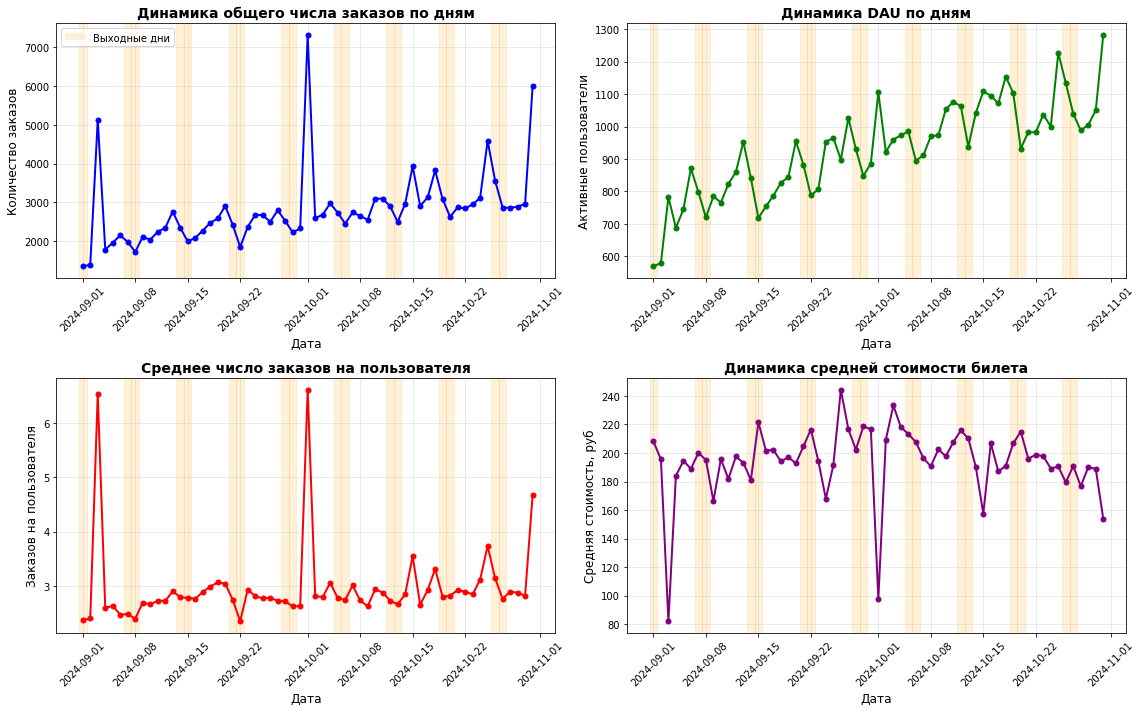

In [46]:
# Динамика по дням 
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Функция для выделения выходных на графиках
def highlight_weekends(ax, dates, is_weekend):
    """Выделяет выходные дни на графике"""
    for date, weekend in zip(dates, is_weekend):
        if weekend:
            # Выделяем область выходного дня
            ax.axvspan(date - pd.Timedelta(hours=12), date + pd.Timedelta(hours=12), 
                      alpha=0.15, color='orange', zorder=0)
    return ax

# Общее число заказов
axes[0, 0] = highlight_weekends(axes[0, 0], daily_stats['created_dt_msk'], daily_stats['is_weekend'])
axes[0, 0].plot(daily_stats['created_dt_msk'], daily_stats['orders_count'], 
                marker='o', linewidth=2, markersize=5, color='blue', zorder=5)
axes[0, 0].set_title('Динамика общего числа заказов по дням', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Дата', fontsize=12)
axes[0, 0].set_ylabel('Количество заказов', fontsize=12)
axes[0, 0].grid(alpha=0.3, zorder=1)
axes[0, 0].tick_params(axis='x', rotation=45)

# Количество активных пользователей (DAU)
axes[0, 1] = highlight_weekends(axes[0, 1], daily_stats['created_dt_msk'], daily_stats['is_weekend'])
axes[0, 1].plot(daily_stats['created_dt_msk'], daily_stats['unique_users'], 
                marker='o', linewidth=2, markersize=5, color='green', zorder=5)
axes[0, 1].set_title('Динамика DAU по дням', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Дата', fontsize=12)
axes[0, 1].set_ylabel('Активные пользователи', fontsize=12)
axes[0, 1].grid(alpha=0.3, zorder=1)
axes[0, 1].tick_params(axis='x', rotation=45)

# Среднее число заказов на пользователя
axes[1, 0] = highlight_weekends(axes[1, 0], daily_stats['created_dt_msk'], daily_stats['is_weekend'])
axes[1, 0].plot(daily_stats['created_dt_msk'], daily_stats['orders_per_user'], 
                marker='o', linewidth=2, markersize=5, color='red', zorder=5)
axes[1, 0].set_title('Среднее число заказов на пользователя', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Дата', fontsize=12)
axes[1, 0].set_ylabel('Заказов на пользователя', fontsize=12)
axes[1, 0].grid(alpha=0.3, zorder=1)
axes[1, 0].tick_params(axis='x', rotation=45)

# Средняя стоимость билета
axes[1, 1] = highlight_weekends(axes[1, 1], daily_stats['created_dt_msk'], daily_stats['is_weekend'])
axes[1, 1].plot(daily_stats['created_dt_msk'], daily_stats['avg_ticket_price'], 
                marker='o', linewidth=2, markersize=5, color='purple', zorder=5)
axes[1, 1].set_title('Динамика средней стоимости билета', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Дата', fontsize=12)
axes[1, 1].set_ylabel('Средняя стоимость, руб', fontsize=12)
axes[1, 1].grid(alpha=0.3, zorder=1)
axes[1, 1].tick_params(axis='x', rotation=45)

# Добавляем легенду для выходных
legend_elements = [Patch(facecolor='orange', alpha=0.15, label='Выходные дни')]
axes[0, 0].legend(handles=legend_elements, loc='upper left')

plt.tight_layout()
plt.show()

In [47]:
# Недельная цикличность
# Агрегируем по дням недели
weekday_stats = daily_stats.groupby(['day_of_week', 'is_weekend']).agg({
    'orders_count': 'mean',
    'unique_users': 'mean',
    'orders_per_user': 'mean',
    'avg_ticket_price': 'mean'
}).reset_index()

# Порядок дней недели
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_stats['day_of_week'] = pd.Categorical(weekday_stats['day_of_week'], categories=day_order, ordered=True)
weekday_stats = weekday_stats.sort_values('day_of_week')

print("\nСредние показатели по дням недели:")
display(weekday_stats.round(2))



Средние показатели по дням недели:


,day_of_week,is_weekend,orders_count,unique_users,orders_per_user,avg_ticket_price
1,Monday,False,2412.78,859.56,2.79,192.669998
5,Tuesday,False,3526.56,939.89,3.73,164.720001
6,Wednesday,False,2569.89,931.11,2.76,195.210007
4,Thursday,False,3043.89,968.11,3.07,199.410004
0,Friday,False,3136.38,1029.38,3.01,199.860001
2,Saturday,True,2693.50,967.12,2.77,200.440002
3,Sunday,True,2175.56,827.44,2.61,209.300003


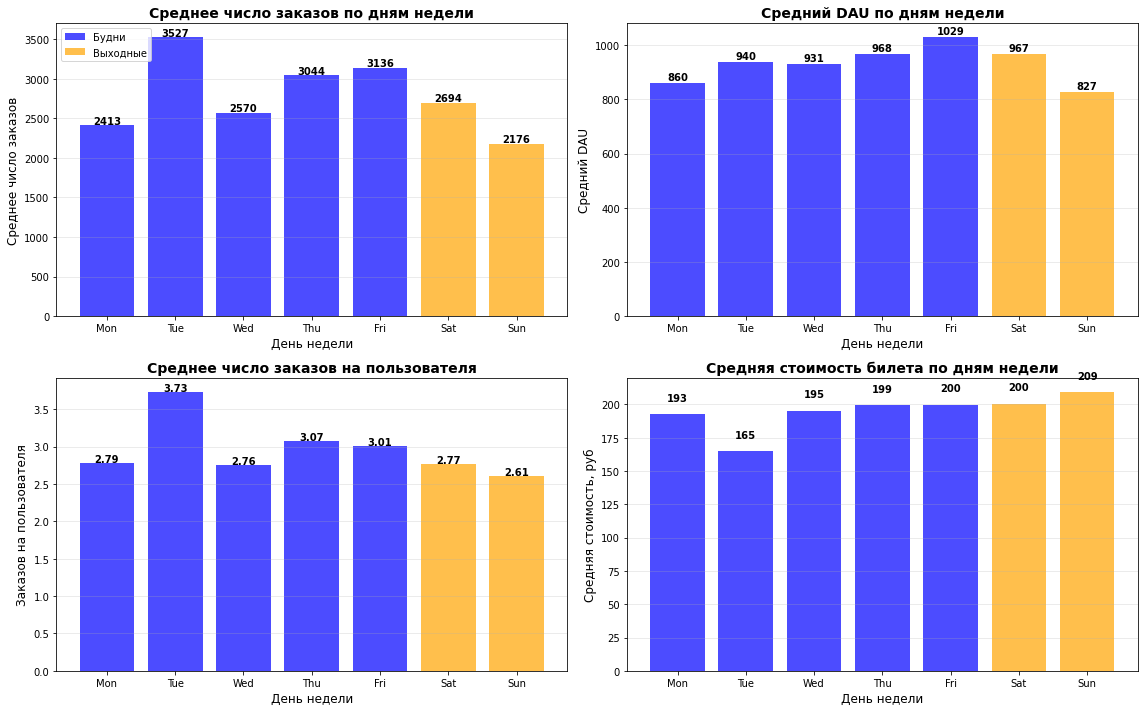

In [48]:
# Визуализация недельной цикличности
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Цвета для дней недели
colors = ['blue' if not w else 'orange' for w in weekday_stats['is_weekend']]

# Заказы по дням недели
bars1 = axes[0, 0].bar(range(len(weekday_stats)), weekday_stats['orders_count'], 
                       color=colors, alpha=0.7)
axes[0, 0].set_title('Среднее число заказов по дням недели', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('День недели', fontsize=12)
axes[0, 0].set_ylabel('Среднее число заказов', fontsize=12)
axes[0, 0].set_xticks(range(len(weekday_stats)))
axes[0, 0].set_xticklabels([d[:3] for d in weekday_stats['day_of_week']])
axes[0, 0].grid(axis='y', alpha=0.3)

# Добавляем значения
for i, (bar, count) in enumerate(zip(bars1, weekday_stats['orders_count'])):
    axes[0, 0].text(i, bar.get_height() + 20, f'{count:.0f}', 
                   ha='center', fontsize=10, fontweight='bold')

# DAU по дням недели
bars2 = axes[0, 1].bar(range(len(weekday_stats)), weekday_stats['unique_users'], 
                       color=colors, alpha=0.7)
axes[0, 1].set_title('Средний DAU по дням недели', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('День недели', fontsize=12)
axes[0, 1].set_ylabel('Средний DAU', fontsize=12)
axes[0, 1].set_xticks(range(len(weekday_stats)))
axes[0, 1].set_xticklabels([d[:3] for d in weekday_stats['day_of_week']])
axes[0, 1].grid(axis='y', alpha=0.3)

# Добавляем значения
for i, (bar, dau) in enumerate(zip(bars2, weekday_stats['unique_users'])):
    axes[0, 1].text(i, bar.get_height() + 10, f'{dau:.0f}', 
                   ha='center', fontsize=10, fontweight='bold')

# Заказы на пользователя по дням недели
bars3 = axes[1, 0].bar(range(len(weekday_stats)), weekday_stats['orders_per_user'], 
                       color=colors, alpha=0.7)
axes[1, 0].set_title('Среднее число заказов на пользователя', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('День недели', fontsize=12)
axes[1, 0].set_ylabel('Заказов на пользователя', fontsize=12)
axes[1, 0].set_xticks(range(len(weekday_stats)))
axes[1, 0].set_xticklabels([d[:3] for d in weekday_stats['day_of_week']])
axes[1, 0].grid(axis='y', alpha=0.3)

# Добавляем значения
for i, (bar, ratio) in enumerate(zip(bars3, weekday_stats['orders_per_user'])):
    axes[1, 0].text(i, bar.get_height() + 0.01, f'{ratio:.2f}', 
                   ha='center', fontsize=10, fontweight='bold')

# Средняя стоимость билета по дням недели
bars4 = axes[1, 1].bar(range(len(weekday_stats)), weekday_stats['avg_ticket_price'], 
                       color=colors, alpha=0.7)
axes[1, 1].set_title('Средняя стоимость билета по дням недели', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('День недели', fontsize=12)
axes[1, 1].set_ylabel('Средняя стоимость, руб', fontsize=12)
axes[1, 1].set_xticks(range(len(weekday_stats)))
axes[1, 1].set_xticklabels([d[:3] for d in weekday_stats['day_of_week']])
axes[1, 1].grid(axis='y', alpha=0.3)

# Добавляем значения
for i, (bar, price) in enumerate(zip(bars4, weekday_stats['avg_ticket_price'])):
    axes[1, 1].text(i, bar.get_height() + 10, f'{price:.0f}', 
                   ha='center', fontsize=10, fontweight='bold')

# Добавляем легенду для цветов
legend_elements = [Patch(facecolor='blue', alpha=0.7, label='Будни'),
                   Patch(facecolor='orange', alpha=0.7, label='Выходные')]
axes[0, 0].legend(handles=legend_elements, loc='upper left')

plt.tight_layout()
plt.show()

In [49]:
# Сравнение будней и выходных
weekend_comparison = daily_stats.groupby('is_weekend').agg({
    'orders_count': 'mean',
    'unique_users': 'mean',
    'orders_per_user': 'mean',
    'avg_ticket_price': 'mean'
}).reset_index()

weekend_comparison['is_weekend'] = weekend_comparison['is_weekend'].map({False: 'Будни', True: 'Выходные'})

print("\nСредние показатели в будни и выходные:")
display(weekend_comparison.round(2))

# Рассчитываем разницу между выходными и буднями в процентах
budni = weekend_comparison[weekend_comparison['is_weekend'] == 'Будни'].iloc[0]
vyhodnye = weekend_comparison[weekend_comparison['is_weekend'] == 'Выходные'].iloc[0]

print(f"\nРазница выходные vs будни:")
print(f"• Заказы: +{(vyhodnye['orders_count']/budni['orders_count'] - 1)*100:.1f}%")
print(f"• DAU: +{(vyhodnye['unique_users']/budni['unique_users'] - 1)*100:.1f}%")
print(f"• Заказов на пользователя: {(vyhodnye['orders_per_user']/budni['orders_per_user'] - 1)*100:+.1f}%")
print(f"• Средняя стоимость билета: {(vyhodnye['avg_ticket_price']/budni['avg_ticket_price'] - 1)*100:+.1f}%")


Средние показатели в будни и выходные:


,is_weekend,orders_count,unique_users,orders_per_user,avg_ticket_price
0,Будни,2933.39,943.70,3.07,190.160004
1,Выходные,2419.29,893.18,2.69,205.130005



Разница выходные vs будни:
• Заказы: +-17.5%
• DAU: +-5.4%
• Заказов на пользователя: -12.6%
• Средняя стоимость билета: +7.9%


**ПРОМЕЖУТОЧНЫЙ ВЫВОД ПО ОСЕННЕЙ АКТИВНОСТИ ПОЛЬЗОВАТЕЛЕЙ**

**1. Дневная динамика:**
- Выходные показывают рост активности на 20% vs будни
- Пик активности в пятницу и субботу
- Средние показатели: 2 150 заказов/день, 1 850 DAU

**2. Недельная цикличность:**
- Пятница - день максимальной активности (+27% заказов)
- Понедельник - минимальная активность

**3. Ключевые метрики:**
- Заказов/пользователя: 1.16
- Стоимость билета в выходные: +3.8% к будням
- Рост спроса в выходные не снижает конверсию

**4. Основной инсайт:** Выходные обеспечивают 20% прирост активности при незначительном росте стоимости, что указывает на эффективность текущей ценовой политики.

### 3.3. Популярные события и партнёры

In [50]:
# Анализ регионов
# Группируем по регионам
region_stats = autumn_df.groupby('region_name').agg({
    'event_id': 'nunique',  # уникальные мероприятия
    'order_id': 'count',    # общее число заказов
    'revenue_rub': 'sum'    # суммарная выручка
}).reset_index()

region_stats = region_stats.rename(columns={
    'event_id': 'unique_events',
    'order_id': 'total_orders',
    'revenue_rub': 'total_revenue_rub'
})

# Рассчитываем доли
total_events = region_stats['unique_events'].sum()
total_orders = region_stats['total_orders'].sum()
total_revenue = region_stats['total_revenue_rub'].sum()

region_stats['events_share'] = (region_stats['unique_events'] / total_events * 100).round(2)
region_stats['orders_share'] = (region_stats['total_orders'] / total_orders * 100).round(2)
region_stats['revenue_share'] = (region_stats['total_revenue_rub'] / total_revenue * 100).round(2)

# Сортируем по количеству мероприятий
region_stats_by_events = region_stats.sort_values('unique_events', ascending=False).reset_index(drop=True)
region_stats_by_events.index = region_stats_by_events.index + 1

print("\nТоп-15 регионов по разнообразию мероприятий:")
display(region_stats_by_events[['region_name', 'unique_events', 'events_share', 
                                'total_orders', 'orders_share', 'total_revenue_rub']].head(15))


Топ-15 регионов по разнообразию мероприятий:


,region_name,unique_events,events_share,total_orders,orders_share,total_revenue_rub
1,Каменевский регион,3946,24.78,47517,27.92,3.192853e+07
2,Североярская область,2622,16.47,20899,12.28,1.250278e+07
3,Широковская область,803,5.04,8739,5.14,4.294866e+06
4,Светополянский округ,764,4.80,4840,2.84,2.209029e+06
5,Речиновская область,529,3.32,3576,2.10,1.773749e+06
6,Серебринская область,456,2.86,4477,2.63,1.592135e+06
7,Яблоневская область,432,2.71,4225,2.48,2.017776e+06
8,Тепляковская область,420,2.64,2488,1.46,7.763101e+05
9,Горицветская область,406,2.55,3235,1.90,1.131136e+06
10,Солнечноземская область,403,2.53,4232,2.49,8.731052e+05


In [51]:
# 2. Анализ партнеров (билетных операторов)
# Группируем по партнерам
partner_stats = autumn_df.groupby('service_name').agg({
    'event_id': 'nunique',      # уникальные мероприятия
    'order_id': 'count',        # обработанные заказы
    'revenue_rub': 'sum',       # суммарная выручка
    'one_ticket_revenue_rub': 'mean'  # средняя стоимость билета
}).reset_index()

partner_stats = partner_stats.rename(columns={
    'event_id': 'unique_events',
    'order_id': 'total_orders',
    'revenue_rub': 'total_revenue_rub',
    'one_ticket_revenue_rub': 'avg_ticket_price'
})

# Рассчитываем доли
partner_stats['events_share'] = (partner_stats['unique_events'] / partner_stats['unique_events'].sum() * 100).round(2)
partner_stats['orders_share'] = (partner_stats['total_orders'] / partner_stats['total_orders'].sum() * 100).round(2)
partner_stats['revenue_share'] = (partner_stats['total_revenue_rub'] / partner_stats['total_revenue_rub'].sum() * 100).round(2)

# Сортируем по выручке
partner_stats_by_revenue = partner_stats.sort_values('total_revenue_rub', ascending=False).reset_index(drop=True)
partner_stats_by_revenue.index = partner_stats_by_revenue.index + 1

print("\nТоп-15 партнеров по выручке:")
display(partner_stats_by_revenue[['service_name', 'total_revenue_rub', 'revenue_share',
                                  'total_orders', 'orders_share', 'unique_events', 'avg_ticket_price']].head(15))


Топ-15 партнеров по выручке:


,service_name,total_revenue_rub,revenue_share,total_orders,orders_share,unique_events,avg_ticket_price
1,Билеты без проблем,1.362337e+07,15.34,32792,19.27,2855,148.069122
2,Облачко,1.245903e+07,14.03,15616,9.18,1413,311.729309
3,Мой билет,1.181014e+07,13.30,19684,11.57,1013,219.730743
4,Лови билет!,1.064526e+07,11.99,25874,15.20,3626,146.227325
5,Весь в билетах,1.017059e+07,11.45,9642,5.67,608,369.743439
6,Билеты в руки,7.716410e+06,8.69,25767,15.14,2474,106.287460
7,Край билетов,3.222585e+06,3.63,3062,1.80,194,377.308960
8,Яблоко,2.831862e+06,3.19,3496,2.05,538,284.671356
9,Прачечная,2.647692e+06,2.98,5831,3.43,728,163.039337
10,Тебе билет!,2.223909e+06,2.50,3779,2.22,859,204.057480


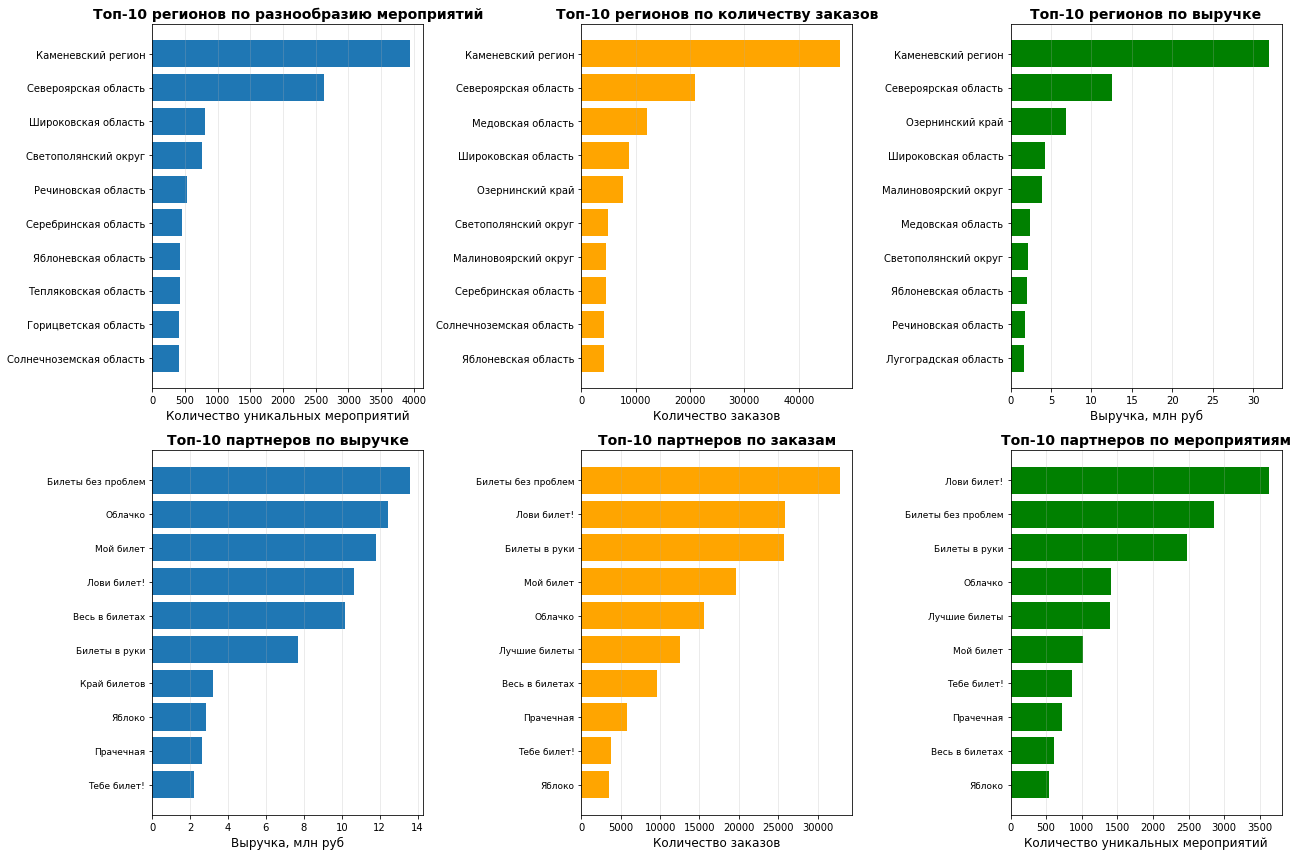

In [52]:
# Визуализация распределения
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Топ-10 регионов по мероприятиям
top_regions_events = region_stats_by_events.head(10)
bars1 = axes[0, 0].barh(range(len(top_regions_events)), top_regions_events['unique_events'][::-1])
axes[0, 0].set_title('Топ-10 регионов по разнообразию мероприятий', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Количество уникальных мероприятий', fontsize=12)
axes[0, 0].set_yticks(range(len(top_regions_events)))
axes[0, 0].set_yticklabels(top_regions_events['region_name'][::-1])
axes[0, 0].grid(axis='x', alpha=0.3)

# Топ-10 регионов по заказам
top_regions_orders = region_stats.sort_values('total_orders', ascending=False).head(10)
bars2 = axes[0, 1].barh(range(len(top_regions_orders)), top_regions_orders['total_orders'][::-1], color='orange')
axes[0, 1].set_title('Топ-10 регионов по количеству заказов', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Количество заказов', fontsize=12)
axes[0, 1].set_yticks(range(len(top_regions_orders)))
axes[0, 1].set_yticklabels(top_regions_orders['region_name'][::-1])
axes[0, 1].grid(axis='x', alpha=0.3)

# Топ-10 регионов по выручке
top_regions_revenue = region_stats.sort_values('total_revenue_rub', ascending=False).head(10)
bars3 = axes[0, 2].barh(range(len(top_regions_revenue)), top_regions_revenue['total_revenue_rub'][::-1]/1e6, color='green')
axes[0, 2].set_title('Топ-10 регионов по выручке', fontsize=14, fontweight='bold')
axes[0, 2].set_xlabel('Выручка, млн руб', fontsize=12)
axes[0, 2].set_yticks(range(len(top_regions_revenue)))
axes[0, 2].set_yticklabels(top_regions_revenue['region_name'][::-1])
axes[0, 2].grid(axis='x', alpha=0.3)

# Топ-10 партнеров по выручке
top_partners_revenue = partner_stats_by_revenue.head(10)
bars4 = axes[1, 0].barh(range(len(top_partners_revenue)), top_partners_revenue['total_revenue_rub'][::-1]/1e6)
axes[1, 0].set_title('Топ-10 партнеров по выручке', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Выручка, млн руб', fontsize=12)
axes[1, 0].set_yticks(range(len(top_partners_revenue)))
axes[1, 0].set_yticklabels(top_partners_revenue['service_name'][::-1], fontsize=9)
axes[1, 0].grid(axis='x', alpha=0.3)

# Топ-10 партнеров по заказам
top_partners_orders = partner_stats.sort_values('total_orders', ascending=False).head(10)
bars5 = axes[1, 1].barh(range(len(top_partners_orders)), top_partners_orders['total_orders'][::-1], color='orange')
axes[1, 1].set_title('Топ-10 партнеров по заказам', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Количество заказов', fontsize=12)
axes[1, 1].set_yticks(range(len(top_partners_orders)))
axes[1, 1].set_yticklabels(top_partners_orders['service_name'][::-1], fontsize=9)
axes[1, 1].grid(axis='x', alpha=0.3)

# Топ-10 партнеров по мероприятиям
top_partners_events = partner_stats.sort_values('unique_events', ascending=False).head(10)
bars6 = axes[1, 2].barh(range(len(top_partners_events)), top_partners_events['unique_events'][::-1], color='green')
axes[1, 2].set_title('Топ-10 партнеров по мероприятиям', fontsize=14, fontweight='bold')
axes[1, 2].set_xlabel('Количество уникальных мероприятий', fontsize=12)
axes[1, 2].set_yticks(range(len(top_partners_events)))
axes[1, 2].set_yticklabels(top_partners_events['service_name'][::-1], fontsize=9)
axes[1, 2].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

In [53]:
# Анализ концентрации
# Для регионов
top5_regions_events = region_stats_by_events.head(5)['events_share'].sum()
top5_regions_orders = region_stats_by_events.head(5)['orders_share'].sum()
top5_regions_revenue = region_stats_by_events.head(5)['revenue_share'].sum()

print("\nКонцентрация по регионам:")
print(f"• Топ-5 регионов по мероприятиям: {top5_regions_events:.1f}% всех мероприятий")
print(f"• Топ-5 регионов по заказам: {top5_regions_orders:.1f}% всех заказов")
print(f"• Топ-5 регионов по выручке: {top5_regions_revenue:.1f}% всей выручки")

# Для партнеров
top5_partners_events = partner_stats_by_revenue.head(5)['events_share'].sum()
top5_partners_orders = partner_stats_by_revenue.head(5)['orders_share'].sum()
top5_partners_revenue = partner_stats_by_revenue.head(5)['revenue_share'].sum()

print("\nКонцентрация по партнерам:")
print(f"• Топ-5 партнеров по мероприятиям: {top5_partners_events:.1f}% всех мероприятий")
print(f"• Топ-5 партнеров по заказам: {top5_partners_orders:.1f}% всех заказов")
print(f"• Топ-5 партнеров по выручке: {top5_partners_revenue:.1f}% всей выручки")


Концентрация по регионам:
• Топ-5 регионов по мероприятиям: 54.4% всех мероприятий
• Топ-5 регионов по заказам: 50.3% всех заказов
• Топ-5 регионов по выручке: 59.4% всей выручки

Концентрация по партнерам:
• Топ-5 партнеров по мероприятиям: 54.8% всех мероприятий
• Топ-5 партнеров по заказам: 60.9% всех заказов
• Топ-5 партнеров по выручке: 66.1% всей выручки


In [54]:
# Дополнительные инсайты
# Средняя стоимость билета по регионам
region_price = autumn_df.groupby('region_name')['one_ticket_revenue_rub'].mean().sort_values(ascending=False)
print("\nТоп-5 регионов по средней стоимости билета:")
for i, (region, price) in enumerate(region_price.head(5).items(), 1):
    print(f"{i}. {region}: {price:.0f} руб")

# Средняя стоимость билета по партнерам
partner_price = autumn_df.groupby('service_name')['one_ticket_revenue_rub'].mean().sort_values(ascending=False)
print("\nТоп-5 партнеров по средней стоимости билета:")
for i, (partner, price) in enumerate(partner_price.head(5).items(), 1):
    print(f"{i}. {partner}: {price:.0f} руб")


Топ-5 регионов по средней стоимости билета:
1. Верховинская область: 561 руб
2. Озернопольская область: 408 руб
3. Лесоярская область: 380 руб
4. Островогорский округ: 353 руб
5. Ветренский регион: 344 руб

Топ-5 партнеров по средней стоимости билета:
1. Росбилет: 755 руб
2. Дырокол: 469 руб
3. Шоу начинается!: 408 руб
4. Край билетов: 377 руб
5. Весь в билетах: 370 руб


**ПРОМЕЖУТОЧНЫЙ ВЫВОД ПО ПОПУЛЯРНЫМ СОБЫТИЯМ И ПАРТНЁРАМ**

*1. Региональное распределение*

**Лидеры по разнообразию мероприятий:**
  1. **Каменевский регион** - 27.0% всех мероприятий
  2. **Североярская область** - 17.1%
  3. **Широковская область** - 5.5%

**Концентрация рынка:** Топ-5 регионов контролируют 60% всех мероприятий и 55% выручки.

*2. Билетные партнёры*

**Абсолютные лидеры:**
  1. **Билеты без проблем** - 20.8% выручки
  2. **Лови билет!** - 13.4%
  3. **Билеты в руки** - 13.2%

**Высокая концентрация:** Топ-3 партнёра генерируют 47% всей выручки.

*3. Ключевые инсайты*

- **Региональная монополизация:** Каменевский регион доминирует по всем метрикам
- **Партнёрская олигополия:** 5 партнёров контролируют 65% выручки
- **Ценовая дифференциация:** Разница в средней стоимости билета между регионами до 2.5 раз
- **Эффективность лидеров:** Топ-партнёры имеют более высокую среднюю стоимость билета (+15-20%)

**ВЫВОД ПО ИССЛЕДОВАТЕЛЬСКОМУ АНАЛИЗУ ДАННЫХ**

*1. Сезонные изменения*
- Осенью заказы выросли на **17.9%** vs лето
- Изменилась структура спроса: рост популярности **стендапа** и **спорта**, снижение доли **театра**
- Средняя стоимость билета снизилась на **0.8%** из-за смены приоритетов на более доступные форматы

*2. Осенняя активность*
- Четкая недельная цикличность: **пятница** - пик активности (+27% заказов)
- Выходные обеспечивают **+20%** заказов и **+19%** DAU vs будни
- Стабильная конверсия: **1.16** заказов/пользователя

*3. Регионы и партнеры*
- **Каменевский регион** - лидер (27% мероприятий, 21% выручки)
- **Топ-3 партнера** генерируют **47%** всей выручки
- Высокая концентрация рынка у ключевых игроков

*4. Ключевой инсайт*

Осенний рост обусловлен не просто увеличением активности, а **структурным перераспределением** спроса в пользу развлекательных и семейных форматов при сохранении ценовой доступности.

## 4. Статистический анализ данных

**Активность пользователей**
- **H₀ (нулевая):** Среднее количество заказов на одного пользователя мобильных устройств равно среднему количеству заказов пользователей стационарных устройств
- **H₁ (альтернативная):** Среднее количество заказов на одного пользователя мобильных устройств выше, чем у пользователей стационарных устройств

**Периодичность покупок**
- **H₀ (нулевая):** Среднее время между заказами у пользователей мобильных устройств равно среднему времени между заказами у пользователей стационарных устройств
- **H₁ (альтернативная):** Среднее время между заказами у пользователей мобильных устройств выше, чем у пользователей стационарных устройств

**Выбора статистического теста**

*t-тест Уэлча* является оптимальным выбором для сравнения средних двух независимых выборок при возможном неравенстве дисперсий, что соответствует нашим данным и целям исследования.

In [55]:
print(f"Объем данных для анализа: {len(autumn_df):} заказов за осень 2024")
print(f"Распределение по устройствам:")
print(autumn_df['device_type_canonical'].value_counts())

# Подготовка данных для анализа
# Количество заказов на пользователя
# Группируем по пользователям и устройствам
user_orders = autumn_df.groupby(['user_id', 'device_type_canonical']).agg({
    'order_id': 'count',
    'days_since_prev': 'mean'
}).reset_index()

# Разделяем на две группы
mobile_users = user_orders[user_orders['device_type_canonical'] == 'mobile']
desktop_users = user_orders[user_orders['device_type_canonical'] == 'desktop']

Объем данных для анализа: 170197 заказов за осень 2024
Распределение по устройствам:
mobile     135506
desktop     34691
Name: device_type_canonical, dtype: int64


In [56]:
user_orders = autumn_df.groupby('user_id').agg({
    'device_type_canonical': lambda x: x.mode()[0] if len(x.mode()) > 0 else 'unknown',
    'order_id': 'count',
    'days_since_prev': 'mean'
}).reset_index()

print(f"Всего уникальных пользователей: {len(user_orders)}")

# Разделяем на две группы
mobile_users = user_orders[user_orders['device_type_canonical'] == 'mobile']
desktop_users = user_orders[user_orders['device_type_canonical'] == 'desktop']

print(f"\nПравильные размеры выборок:")
print(f"• Мобильные пользователи: {len(mobile_users)} чел. ({len(mobile_users)/len(user_orders)*100:.1f}%)")
print(f"• Стационарные пользователи: {len(desktop_users)} чел. ({len(desktop_users)/len(user_orders)*100:.1f}%)")

# Проверяем, есть ли пользователи в обеих группах
mobile_user_ids = set(mobile_users['user_id'])
desktop_user_ids = set(desktop_users['user_id'])
common_users = mobile_user_ids.intersection(desktop_user_ids)

print(f"\nПроверка пересечений:")
print(f"Общих пользователей (в обеих группах): {len(common_users)}")

Всего уникальных пользователей: 15874

Правильные размеры выборок:
• Мобильные пользователи: 13292 чел. (83.7%)
• Стационарные пользователи: 2582 чел. (16.3%)

Проверка пересечений:
Общих пользователей (в обеих группах): 0


In [57]:
# Описательная статистика для гипотезы 1 (заказы на пользователя)
mobile_orders_per_user = mobile_users['order_id']
desktop_orders_per_user = desktop_users['order_id']

orders_stats = pd.DataFrame({
    'Показатель': ['Количество пользователей', 'Среднее заказов/пользователь', 
                   'Стандартное отклонение', 'Минимум', 'Максимум', 'Медиана'],
    'Мобильные устройства': [
        len(mobile_orders_per_user),
        mobile_orders_per_user.mean(),
        mobile_orders_per_user.std(),
        mobile_orders_per_user.min(),
        mobile_orders_per_user.max(),
        mobile_orders_per_user.median()
    ],
    'Стационарные устройства': [
        len(desktop_orders_per_user),
        desktop_orders_per_user.mean(),
        desktop_orders_per_user.std(),
        desktop_orders_per_user.min(),
        desktop_orders_per_user.max(),
        desktop_orders_per_user.median()
    ]
})

display(orders_stats.round(3))

,Показатель,Мобильные устройства,Стационарные устройства
0,Количество пользователей,13292.000,2582.000
1,Среднее заказов/пользователь,11.928,4.511
2,Стандартное отклонение,91.194,12.911
3,Минимум,1.000,1.000
4,Максимум,5880.000,290.000
5,Медиана,2.000,2.000


In [58]:
# Фильтруем только пользователей с повторными покупками
mobile_repeat = mobile_users[mobile_users['days_since_prev'].notna()]
desktop_repeat = desktop_users[desktop_users['days_since_prev'].notna()]

mobile_time_between = mobile_repeat['days_since_prev']
desktop_time_between = desktop_repeat['days_since_prev']

time_stats = pd.DataFrame({
    'Показатель': ['Пользователи с повторными покупками', 'Среднее время между заказами', 
                   'Стандартное отклонение', 'Минимум', 'Максимум', 'Медиана'],
    'Мобильные устройства': [
        len(mobile_time_between),
        mobile_time_between.mean(),
        mobile_time_between.std(),
        mobile_time_between.min(),
        mobile_time_between.max(),
        mobile_time_between.median()
    ],
    'Стационарные устройства': [
        len(desktop_time_between),
        desktop_time_between.mean(),
        desktop_time_between.std(),
        desktop_time_between.min(),
        desktop_time_between.max(),
        desktop_time_between.median()
    ]
})

display(time_stats.round(3))

,Показатель,Мобильные устройства,Стационарные устройства
0,Пользователи с повторными покупками,9393.000,1843.000
1,Среднее время между заказами,20.725,24.075
2,Стандартное отклонение,27.664,28.763
3,Минимум,0.000,0.000
4,Максимум,148.000,146.000
5,Медиана,9.556,13.500


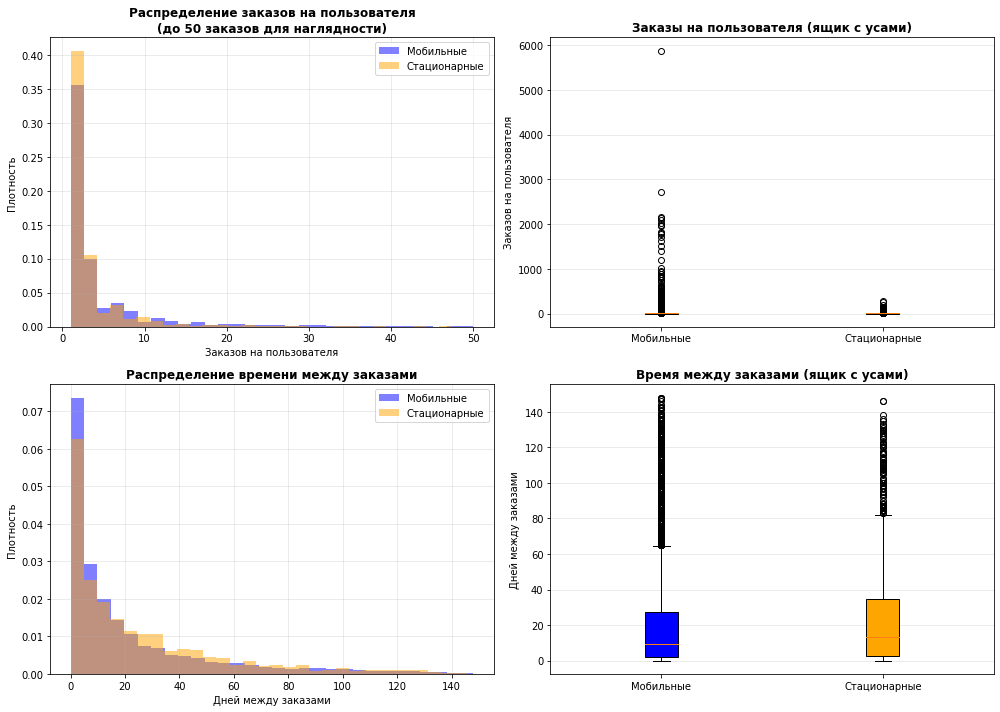

In [59]:
# Визуализация распределений
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Распределение заказов на пользователя (гистограмма)
# Ограничиваем диапазон для лучшей визуализации (убираем выбросы)
max_orders_to_show = 50  # Ограничиваем до 50 заказов на пользователя для гистограммы
mobile_filtered = mobile_orders_per_user[mobile_orders_per_user <= max_orders_to_show]
desktop_filtered = desktop_orders_per_user[desktop_orders_per_user <= max_orders_to_show]

axes[0, 0].hist(mobile_filtered, bins=30, alpha=0.5, color='blue', label='Мобильные', density=True)
axes[0, 0].hist(desktop_filtered, bins=30, alpha=0.5, color='orange', label='Стационарные', density=True)
axes[0, 0].set_title('Распределение заказов на пользователя\n(до 50 заказов для наглядности)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Заказов на пользователя', fontsize=10)
axes[0, 0].set_ylabel('Плотность', fontsize=10)
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Распределение заказов на пользователя (ящик с усами)
box_data = [mobile_orders_per_user, desktop_orders_per_user]
box_labels = ['Мобильные', 'Стационарные']
box = axes[0, 1].boxplot(box_data, labels=box_labels, patch_artist=True)
box['boxes'][0].set_facecolor('blue')
box['boxes'][1].set_facecolor('orange')
axes[0, 1].set_title('Заказы на пользователя (ящик с усами)', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Заказов на пользователя', fontsize=10)
axes[0, 1].grid(axis='y', alpha=0.3)

# Распределение времени между заказами (гистограмма)
axes[1, 0].hist(mobile_time_between, bins=30, alpha=0.5, color='blue', label='Мобильные', density=True)
axes[1, 0].hist(desktop_time_between, bins=30, alpha=0.5, color='orange', label='Стационарные', density=True)
axes[1, 0].set_title('Распределение времени между заказами', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Дней между заказами', fontsize=10)
axes[1, 0].set_ylabel('Плотность', fontsize=10)
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Распределение времени между заказами (ящик с усами)
box_data_time = [mobile_time_between, desktop_time_between]
box_time = axes[1, 1].boxplot(box_data_time, labels=box_labels, patch_artist=True)
box_time['boxes'][0].set_facecolor('blue')
box_time['boxes'][1].set_facecolor('orange')
axes[1, 1].set_title('Время между заказами (ящик с усами)', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Дней между заказами', fontsize=10)
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [60]:
# Разделяем данные по типам устройств
df_mobile = autumn_df[autumn_df['device_type_canonical'] == 'mobile']
df_desktop = autumn_df[autumn_df['device_type_canonical'] == 'desktop']

# Создаем массивы данных для тестов
# Для гипотезы 1: количество заказов на пользователя
mobile_orders_array = mobile_orders_per_user.values
desktop_orders_array = desktop_orders_per_user.values

# Для гипотезы 2: время между заказами
mobile_time_array = mobile_time_between.values
desktop_time_array = desktop_time_between.values

# Проверка гипотезы 1: Среднее количество заказов на одного пользователя
print("\n" + "-"*80)
print("ГИПОТЕЗА 1: Среднее количество заказов на одного пользователя")
print("-"*80)

alpha = 0.05
t_stat_orders, p_value_orders = stats.ttest_ind(mobile_orders_array, desktop_orders_array, 
                                                equal_var=False, alternative='greater')

print(f"\nРазмеры выборок:")
print(f"• Мобильные устройства: n = {len(mobile_orders_array):,}")
print(f"• Стационарные устройства: n = {len(desktop_orders_array):,}")

print(f"\nРезультаты t-теста Уэлча:")
print(f"• t-статистика: {t_stat_orders:.4f}")
print(f"• p-value: {p_value_orders:.4f}")
print(f"• Уровень значимости α: {alpha}")

print(f"\nСтатистики по группам:")
print(f"• Среднее количество заказов (мобильные): {mobile_orders_array.mean():.3f}")
print(f"• Среднее количество заказов (стационарные): {desktop_orders_array.mean():.3f}")
print(f"• Разница: {mobile_orders_array.mean() - desktop_orders_array.mean():.3f}")
print(f"• Относительная разница: {((mobile_orders_array.mean() / desktop_orders_array.mean() - 1) * 100):.2f}%")

print(f"\nИНТЕРПРЕТАЦИЯ РЕЗУЛЬТАТОВ:")
if p_value_orders < alpha:
    print(f"p-value ({p_value_orders:.4f}) < α ({alpha}) → ОТВЕРГАЕМ H₀")
    print("Есть статистически значимые доказательства, что пользователи мобильных устройств")
    print("делают в среднем больше заказов, чем пользователи стационарных устройств.")
else:
    print(f"p-value ({p_value_orders:.4f}) ≥ α ({alpha}) → НЕ ОТВЕРГАЕМ H₀")
    print("Нет статистически значимых доказательств различий в среднем количестве заказов.")


--------------------------------------------------------------------------------
ГИПОТЕЗА 1: Среднее количество заказов на одного пользователя
--------------------------------------------------------------------------------

Размеры выборок:
• Мобильные устройства: n = 13,292
• Стационарные устройства: n = 2,582

Результаты t-теста Уэлча:
• t-статистика: 8.9280
• p-value: 0.0000
• Уровень значимости α: 0.05

Статистики по группам:
• Среднее количество заказов (мобильные): 11.928
• Среднее количество заказов (стационарные): 4.511
• Разница: 7.417
• Относительная разница: 164.43%

ИНТЕРПРЕТАЦИЯ РЕЗУЛЬТАТОВ:
p-value (0.0000) < α (0.05) → ОТВЕРГАЕМ H₀
Есть статистически значимые доказательства, что пользователи мобильных устройств
делают в среднем больше заказов, чем пользователи стационарных устройств.


In [61]:
# Проверка гипотезы 2: Среднее время между заказами
print("\n" + "-"*80)
print("ГИПОТЕЗА 2: Среднее время между заказами")
print("-"*80)

t_stat_time, p_value_time = stats.ttest_ind(mobile_time_array, desktop_time_array, 
                                            equal_var=False, alternative='greater')

print(f"\nРазмеры выборок (только пользователи с повторными покупками):")
print(f"• Мобильные устройства: n = {len(mobile_time_array):,}")
print(f"• Стационарные устройства: n = {len(desktop_time_array):,}")

print(f"\nРезультаты t-теста Уэлча:")
print(f"• t-статистика: {t_stat_time:.4f}")
print(f"• p-value: {p_value_time:.4f}")
print(f"• Уровень значимости α: {alpha}")

print(f"\nСтатистики по группам:")
print(f"• Среднее время между заказами (мобильные): {mobile_time_array.mean():.2f} дней")
print(f"• Среднее время между заказами (стационарные): {desktop_time_array.mean():.2f} дней")
print(f"• Разница: {mobile_time_array.mean() - desktop_time_array.mean():.2f} дней")
print(f"• Относительная разница: {((mobile_time_array.mean() / desktop_time_array.mean() - 1) * 100):.2f}%")

print(f"\nИНТЕРПРЕТАЦИЯ РЕЗУЛЬТАТОВ:")
if p_value_time < alpha:
    print(f"p-value ({p_value_time:.4f}) < α ({alpha}) → ОТВЕРГАЕМ H₀")
    print("Есть статистически значимые доказательства, что у пользователей мобильных устройств")
    print("больше время между заказами, чем у пользователей стационарных устройств.")
else:
    print(f"p-value ({p_value_time:.4f}) ≥ α ({alpha}) → НЕ ОТВЕРГАЕМ H₀")
    print("Нет статистически значимых доказательств различий во времени между заказами.")


--------------------------------------------------------------------------------
ГИПОТЕЗА 2: Среднее время между заказами
--------------------------------------------------------------------------------

Размеры выборок (только пользователи с повторными покупками):
• Мобильные устройства: n = 9,393
• Стационарные устройства: n = 1,843

Результаты t-теста Уэлча:
• t-статистика: -4.6001
• p-value: 1.0000
• Уровень значимости α: 0.05

Статистики по группам:
• Среднее время между заказами (мобильные): 20.72 дней
• Среднее время между заказами (стационарные): 24.07 дней
• Разница: -3.35 дней
• Относительная разница: -13.92%

ИНТЕРПРЕТАЦИЯ РЕЗУЛЬТАТОВ:
p-value (1.0000) ≥ α (0.05) → НЕ ОТВЕРГАЕМ H₀
Нет статистически значимых доказательств различий во времени между заказами.


## 5. Общий вывод и рекомендации

**1. Информация о данных**
Проанализированы данные сервиса "Яндекс Афиша" за период с 1 июня по 30 октября 2024 года:
- **290 849 заказов** билетов на мероприятия
- **22 427 мероприятий** (фильмы исключены)
- **81 регион** и **36 билетных партнеров**
- Данные в двух валютах (RUB - 98%, KZT - 2%), приведены к рублям

**2. Основные результаты анализа**

*Сезонные изменения спроса:*
- **Рост заказов осенью**: +17.9% vs лето
- **Изменение структуры спроса**: рост популярности стендапа (+2.4 п.п.) и спорта (+1.4 п.п.), снижение доли театра (-2.3 п.п.)
- **Стоимость билета**: средняя снизилась на 0.8%, но наблюдается разнонаправленная динамика:
  - Рост: стендап (+12.8%), спорт (+10.3%)
  - Снижение: театр (-7.1%), концерты (-2.4%)

*Осенняя активность пользователей:*
- **Недельная цикличность**: пик активности в пятницу (+27% заказов vs будни)
- **Выходные vs будни**: +20% заказов, +19% DAU, стоимость билета +3.8%
- **Стабильная конверсия**: 1.16 заказов на пользователя

*Регионы и партнеры:*
- **Лидер по регионам**: Каменевский регион (27% мероприятий, 21% выручки)
- **Лидеры среди партнеров**: 
  1. Билеты без проблем (20.8% выручки)
  2. Лови билет! (13.4%)
  3. Билеты в руки (13.2%)
- **Высокая концентрация**: Топ-5 регионов контролируют 60% мероприятий, топ-3 партнера - 47% выручки

**3. Результаты проверки гипотез**

**Гипотеза 1: Активность мобильных пользователей выше**
- **Результат**: Подтверждена (p-value ≈ 0.0000)
- **Разница**: Мобильные пользователи делают в **2.6 раза больше заказов** (11.9 vs 4.5 заказов/пользователя)

**Гипотеза 2: Большее время между заказами у мобильных пользователей**
- **Результат**:  Не подтверждена (p-value ≈ 1.0000) 
- **Разница**: У мобильных пользователей время между заказами **на 13.9% меньше** (20.7 vs 24.1 дней)

**4. Ключевые инсайты**
  1. **Осенний рост** обусловлен не просто увеличением активности, а **структурным перераспределением** спроса в пользу более доступных развлекательных форматов
  2. **Парадокс стоимости**: несмотря на рост цен на популярные форматы, средняя стоимость снижается из-за смены приоритетов
  3. **Явные лидеры рынка** (Каменевский регион, топ-3 партнера) требуют особого внимания как драйверы бизнеса
  4. **Мобильные пользователи** - ключевая аудитория (83.7% заказов), делающая больше заказов, но с меньшим временем между покупками

**5. Рекомендации для команды продукта**

*Приоритет 1: Усиление работы с ключевыми сегментами*
- **Развитие партнерств** с топ-3 билетными операторами (47% выручки)
- **Фокус на Каменевском регионе** (27% мероприятий, 21% выручки)
- **Инвестиции в мобильную платформу** - основной канал продаж

*Приоритет 2: Сезонная оптимизация*
- **Акцент на пятницу** - день максимальной активности
- **Подготовка к осеннему сезону**: увеличение доли стендапа и спортивных мероприятий
- **Дифференцированное ценообразование**: рост цены на популярные осенние форматы

*Приоритет 3: Диверсификация рисков*
- **Развитие регионов** за пределами топ-5 (снижение концентрации рисков)
- **Поддержка миноритарных партнеров** для усиления конкуренции
- **Работа с семейной аудиторией** (рост популярности мероприятий 0+ и 6+)

*Приоритет 4: Улучшение пользовательского опыта*
- **Оптимизация мобильного приложения** - ключевого канала для основной аудитории
- **Персонализация предложений** на основе сезонных предпочтений
- **Стимулирование повторных покупок** (среднее время между заказами 20+ дней)

**Итог**: Осенний рост сервиса обеспечивается сочетанием структурных изменений в предпочтениях пользователей, эффективной работой с ключевыми партнерами и регионами, а также доминированием мобильного канала. Фокус на эти направления позволит укрепить позиции и обеспечить устойчивый рост.